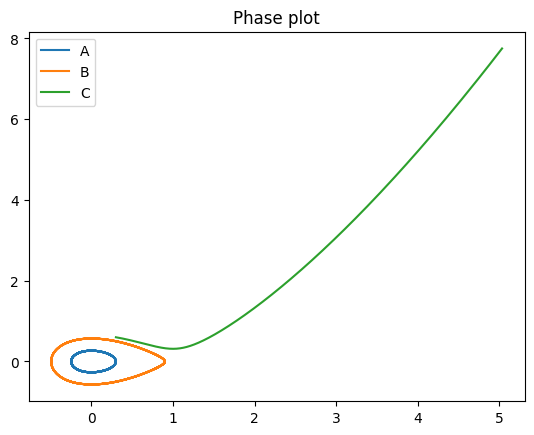

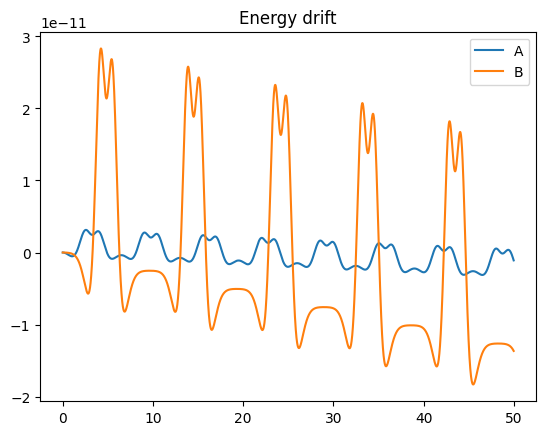

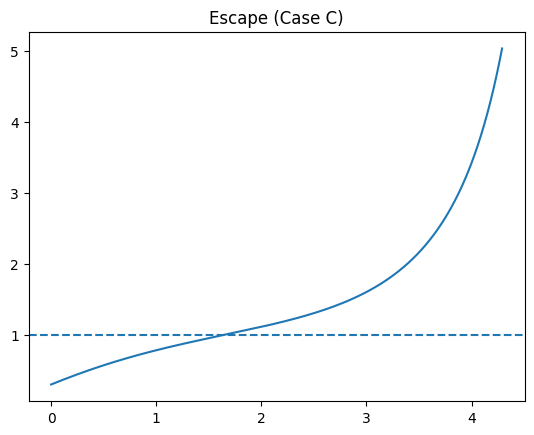

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# ODE system
# -------------------------------
def f(t, y):
    xi, v = y
    return np.array([v, -xi + xi**2])

# -------------------------------
# RK4 step
# -------------------------------
def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h*k1/2)
    k3 = f(t + h/2, y + h*k2/2)
    k4 = f(t + h, y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# -------------------------------
# Parameters
# -------------------------------
dt = 0.01

# -------------------------------
# CASE A (tau up to 50)
# -------------------------------
tA = np.arange(0, 50, dt)

y = np.zeros((len(tA),2))
y[0] = [0.3, 0.0]

for i in range(len(tA)-1):
    y[i+1] = rk4_step(f, tA[i], y[i], dt)

xiA = y[:,0]
vA  = y[:,1]
EA  = 0.5*vA**2 + 0.5*xiA**2 - (1/3)*xiA**3


# -------------------------------
# CASE B (tau up to 50)
# -------------------------------
tB = np.arange(0, 50, dt)

y = np.zeros((len(tB),2))
y[0] = [0.9, 0.0]

for i in range(len(tB)-1):
    y[i+1] = rk4_step(f, tB[i], y[i], dt)

xiB = y[:,0]
vB  = y[:,1]
EB  = 0.5*vB**2 + 0.5*xiB**2 - (1/3)*xiB**3


# -------------------------------
# CASE C (tau up to 100 or escape)
# -------------------------------
tC_full = np.arange(0, 100, dt)

y = np.zeros((len(tC_full),2))
y[0] = [0.3, 0.6]

for i in range(len(tC_full)-1):
    y[i+1] = rk4_step(f, tC_full[i], y[i], dt)
    
    if y[i+1,0] > 5:
        break

xiC = y[:i+2,0]
vC  = y[:i+2,1]
tC  = tC_full[:i+2]


# -------------------------------
# PLOTS
# -------------------------------

# Phase plot
plt.figure()
plt.plot(xiA, vA, label="A")
plt.plot(xiB, vB, label="B")
plt.plot(xiC, vC, label="C")
plt.title("Phase plot")
plt.legend()

# Energy drift
plt.figure()
plt.plot(tA, EA - EA[0], label="A")
plt.plot(tB, EB - EB[0], label="B")
plt.title("Energy drift")
plt.legend()

# Escape trajectory
plt.figure()
plt.plot(tC, xiC)
plt.axhline(1, linestyle="--")
plt.title("Escape (Case C)")

plt.show()

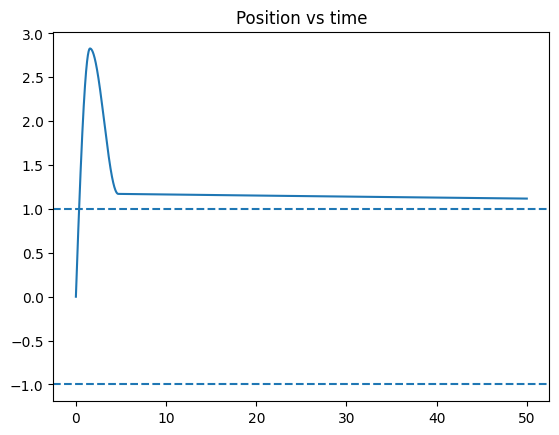

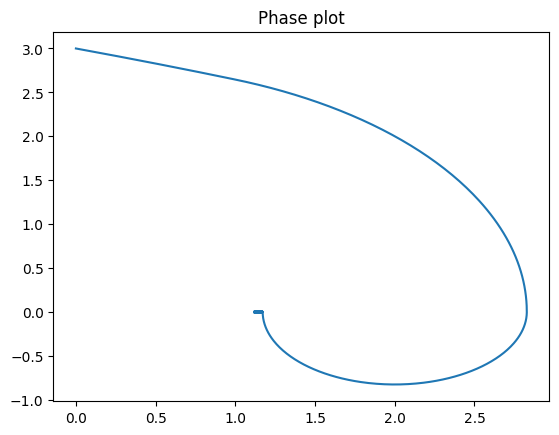

In [2]:
#Q2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# ODE system (piecewise + drag)
# -------------------------------
def f(t, y):
    xi, v = y
    
    # sign function
    if v > 0:
        s = 1
    elif v < 0:
        s = -1
    else:
        s = 0
    
    # piecewise acceleration
    if xi <= -1:
        acc = -(xi + 1) - s
    elif xi >= 1:
        acc = -(xi - 1) - s
    else:
        acc = -s
    
    return np.array([v, acc])


# -------------------------------
# RK4 step
# -------------------------------
def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h*k1/2)
    k3 = f(t + h/2, y + h*k2/2)
    k4 = f(t + h, y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6


# -------------------------------
# Simulation
# -------------------------------
dt = 0.01
t = np.arange(0, 50, dt)

y = np.zeros((len(t),2))
y[0] = [0.0, 3.0]   # initial condition

for i in range(len(t)-1):
    y[i+1] = rk4_step(f, t[i], y[i], dt)

xi = y[:,0]
v  = y[:,1]


# -------------------------------
# PLOTS
# -------------------------------

# Position vs time
plt.figure()
plt.plot(t, xi)
plt.axhline(1, linestyle="--")
plt.axhline(-1, linestyle="--")
plt.title("Position vs time")

# Phase plot
plt.figure()
plt.plot(xi, v)
plt.title("Phase plot")

plt.show()


# -------------------------------
# INTERPRETATION (Q2 d)
# -------------------------------

# The numerical solution shows that the particle initially moves from the flat region 
# into the harmonic wall due to its high initial velocity. However, due to the presence 
# of drag, the particle continuously loses energy during motion.

# As time progresses, the amplitude of oscillation decreases. The particle is no longer 
# able to reach the boundaries at xi = ±1 after some time, indicating that its kinetic 
# energy has reduced sufficiently.

# Eventually, the particle becomes trapped within the flat region (|xi| < 1), where it 
# comes to rest. This confirms the analytical result from part (b).

# The phase plot shows a spiraling trajectory toward the origin, which is characteristic 
# of dissipative systems with energy loss due to drag.

Energies: [np.float64(-2.873887018491443), np.float64(-2.839513715432463), np.float64(-0.2004286891699839)]


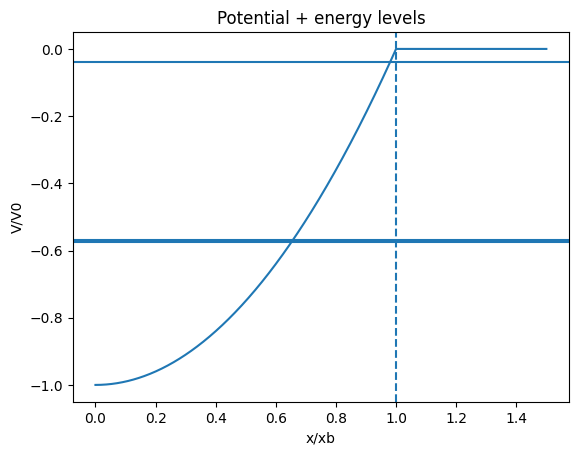

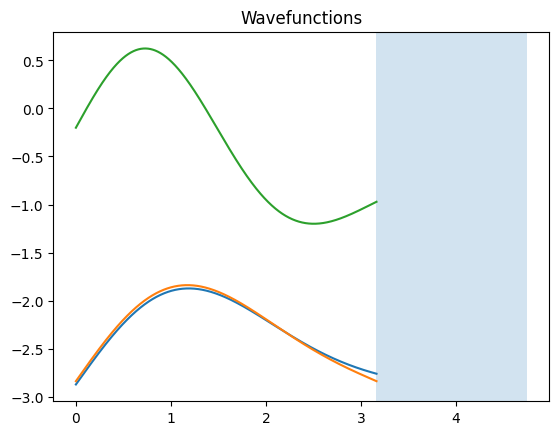

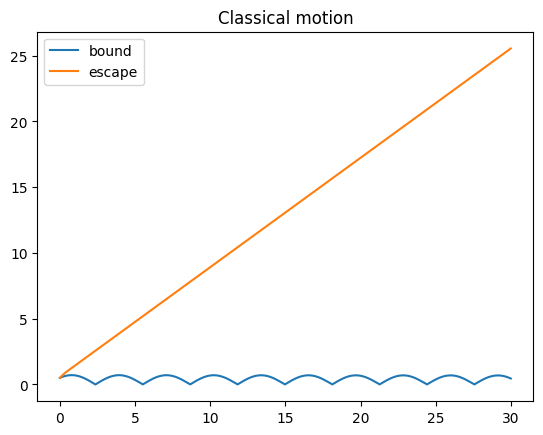

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# PARAMETERS
# -------------------------------
alpha = 5
xb = np.sqrt(2*alpha)

# -------------------------------
# POTENTIAL
# -------------------------------
def V(x):
    if x <= xb:
        return 0.5*x**2 - alpha
    else:
        return 0

# -------------------------------
# RK4 (FROM YOUR NOTEBOOK)
# -------------------------------
def rk4_step(f, x, y, h, E=None):
    k1 = f(x, y, E)
    k2 = f(x + h/2, y + h*k1/2, E)
    k3 = f(x + h/2, y + h*k2/2, E)
    k4 = f(x + h, y + h*k3, E)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# -------------------------------
# SCHRODINGER SYSTEM
# -------------------------------
def f_sch(x, y, E):
    psi, phi = y
    return np.array([phi, (V(x) - E)*psi])

# -------------------------------
# SHOOTING FUNCTION
# -------------------------------
def shoot(E):
    x = np.linspace(0, xb, 1000)
    h = x[1] - x[0]
    
    y = np.zeros((len(x),2))
    y[0] = [0,1]
    
    for i in range(len(x)-1):
        y[i+1] = rk4_step(f_sch, x[i], y[i], h, E)
    
    psi, phi = y[-1]
    kappa = np.sqrt(-2*E)
    
    return phi/psi + kappa

# -------------------------------
# BISECTION
# -------------------------------
def find_root(E1, E2):
    for _ in range(40):
        Em = 0.5*(E1+E2)
        if shoot(E1)*shoot(Em) < 0:
            E2 = Em
        else:
            E1 = Em
    return 0.5*(E1+E2)

# -------------------------------
# FIND ENERGIES
# -------------------------------
E_vals = np.linspace(-alpha,0,200)
energies = []

for i in range(len(E_vals)-1):
    if shoot(E_vals[i])*shoot(E_vals[i+1]) < 0:
        energies.append(find_root(E_vals[i],E_vals[i+1]))

print("Energies:", energies)

# -------------------------------
# PLOT POTENTIAL + LEVELS
# -------------------------------
x = np.linspace(0, 1.5*xb, 1000)
Vplot = [V(xi)/alpha for xi in x]

plt.figure()
plt.plot(x/xb, Vplot)

for E in energies:
    plt.axhline(E/alpha)

plt.axvline(1, linestyle='--')
plt.title("Potential + energy levels")
plt.xlabel("x/xb")
plt.ylabel("V/V0")
plt.show()

# -------------------------------
# WAVEFUNCTIONS
# -------------------------------
plt.figure()

for E in energies[:3]:
    x = np.linspace(0, xb, 1000)
    h = x[1]-x[0]
    
    y = np.zeros((len(x),2))
    y[0] = [0,1]
    
    for i in range(len(x)-1):
        y[i+1] = rk4_step(f_sch, x[i], y[i], h, E)
    
    psi = y[:,0]
    psi = psi/np.max(np.abs(psi))
    
    plt.plot(x, psi + E)

plt.axvspan(xb, 1.5*xb, alpha=0.2)
plt.title("Wavefunctions")
plt.show()

# -------------------------------
# CLASSICAL TRAJECTORY
# -------------------------------
def f_class(t, y, E=None):
    xi, v = y
    
    if xi < 0:
        return np.array([v, -v])  
    
    if xi <= 1:
        return np.array([v, -xi])
    else:
        return np.array([v, 0])

def simulate(x0,v0):
    t = np.arange(0,30,0.01)
    y = np.zeros((len(t),2))
    y[0] = [x0,v0]
    
    for i in range(len(t)-1):
        y[i+1] = rk4_step(f_class,t[i],y[i],0.01)
        if y[i+1,0] < 0:
            y[i+1,1] *= -1
    
    return t,y[:,0]

# plot trajectories
t,xi = simulate(0.5,0.5)
plt.plot(t,xi,label="bound")

t,xi = simulate(0.5,1.2)
plt.plot(t,xi,label="escape")

plt.legend()
plt.title("Classical motion")
plt.show()

Check S(E):
-0.8 0.3141133205496299 0.31415926535897926
-0.5 0.7852833013348068 0.7853981633974483
-0.2 1.2564532821985204 1.2566370614359172
WKB energies: [-0.8333333333333334, -0.5, -0.16666666666666663]


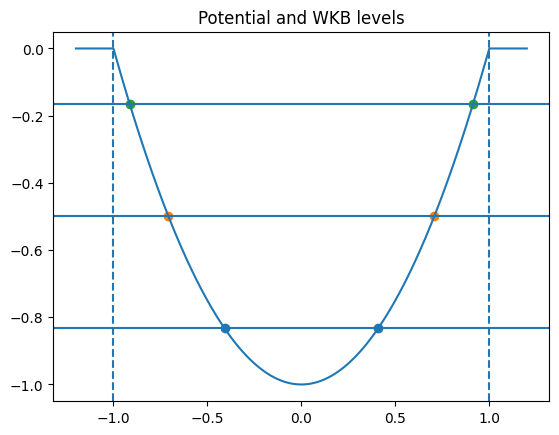

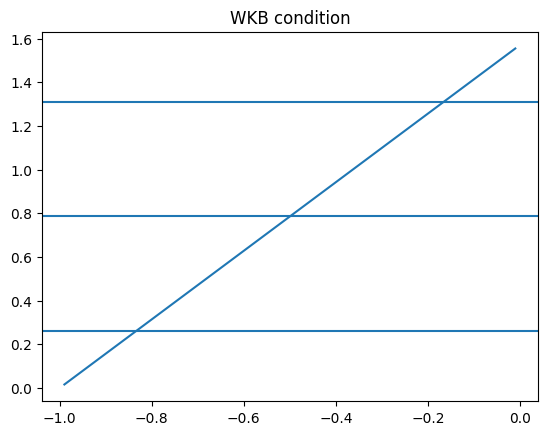

In [7]:
#Q4
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# PARAMETERS
# -------------------------------
Lambda = 6

# -------------------------------
# S(E) using YOUR Simpson style
# -------------------------------
def S_numeric(E):

    N = 200   # must be even
    a = -np.sqrt(1+E)
    b =  np.sqrt(1+E)
    
    xi = np.linspace(a, b, N+1)
    h = (b-a)/N

    val = 1 + E - xi**2
    val[val < 0] = 0   # avoid sqrt issue

    f = np.sqrt(val)

    S = f[0] + f[-1]
    S += 4*np.sum(f[1:-1:2])
    S += 2*np.sum(f[2:-2:2])
    S = S * (h/3)

    return S

# -------------------------------
# EXACT S(E)
# -------------------------------
def S_exact(E):
    return np.pi/2 * (1+E)

# -------------------------------
# CHECK Simpson vs exact
# -------------------------------
print("Check S(E):")
for E in [-0.8, -0.5, -0.2]:
    print(E, S_numeric(E), S_exact(E))

# -------------------------------
# WKB energies
# -------------------------------
energies = []

for n in range(10):
    E = (2*n+1)/Lambda - 1
    if -1 < E < 0:
        energies.append(E)

print("WKB energies:", energies)

# -------------------------------
# POTENTIAL
# -------------------------------
def V(xi):
    if abs(xi) <= 1:
        return xi**2 - 1
    else:
        return 0

# -------------------------------
# PLOT 1: Potential + levels
# -------------------------------
xi = np.linspace(-1.2, 1.2, 1000)
Vplot = np.array([V(x) for x in xi])

plt.figure()
plt.plot(xi, Vplot)

# energy lines
for E in energies:
    plt.axhline(E)

# turning points
for E in energies:
    tp = np.sqrt(1+E)
    plt.scatter([tp, -tp], [E, E])

plt.axvline(1, linestyle='--')
plt.axvline(-1, linestyle='--')

plt.title("Potential and WKB levels")
plt.show()

# -------------------------------
# PLOT 2: S(E) vs E
# -------------------------------
E_scan = np.linspace(-0.99, -0.01, 200)
S_vals = []

for E in E_scan:
    S_vals.append(S_numeric(E))

plt.figure()
plt.plot(E_scan, S_vals)

# WKB lines
for n in range(len(energies)):
    plt.axhline((n+0.5)*np.pi/Lambda)

plt.title("WKB condition")
plt.show()

# Q1, 2025 Endsem (Aranya)
## Rising Gas Bubble — Analytical Model

We consider a spherical air bubble rising in water with a pressure gradient.

---

## Pressure profile

The hydrostatic pressure at height $y$ is:

$$
P(y) = P_a + \rho_\ell g (H - y)
$$

At the bottom ($y = 0$):

$$
P_0 = P_a + \rho_\ell g H
$$

---

## Radius variation (ideal gas law)

Using the ideal gas law:

$$
P V = \text{constant}
$$

Since $V = \frac{4}{3}\pi R^3$, we get:

$$
P(y) R^3(y) = P_0 R_0^3
$$

Hence,

$$
R(y) = R_0 \left(\frac{P_0}{P(y)}\right)^{1/3}
$$

---

## Gas density

Since density is inversely proportional to volume and $PV = \text{const}$:

$$
\rho_g(y) = \rho_{g0} \frac{P(y)}{P_0}
$$

---

## Forces acting on the bubble

- **Buoyancy force:**
$$
F_b = \rho_\ell g V
$$

- **Weight of gas:**
$$
F_g = \rho_g g V
$$

- **Drag force (Stokes regime):**
$$
F_d = 6\pi \mu R v
$$

---

## Effective mass

The bubble accelerates an effective mass:

$$
m_{\text{eff}} = \rho_g V + \frac{1}{2}\rho_\ell V
$$

---

## Equation of motion

Applying Newton’s second law:

$$
m_{\text{eff}}(y)\,\ddot{y}
=
(\rho_\ell - \rho_g(y))\, g\, V(y)
-
6\pi \mu R(y)\,\dot{y}
$$

---

## First-order system

Define velocity:

$$
\dot{y} = v
$$

Then:

$$
\dot{v} =
\frac{(\rho_\ell - \rho_g(y)) g V(y) - 6\pi \mu R(y)\, v}{m_{\text{eff}}(y)}
$$

---

## Reynolds number

To check validity of Stokes drag:

$$
Re = \frac{2\rho_\ell R v}{\mu}
$$

---

## Physical interpretation

- As the bubble rises, pressure decreases → **radius increases**
- Density difference increases → **stronger buoyancy**
- Drag increases with velocity
- If $Re \gtrsim 1$, Stokes drag assumption breaks down

Rise time: 0.5614
Max velocity: 2.263723564980696
Final radius: 0.0010312925935014462
Final volume: 4.594458209314922e-09


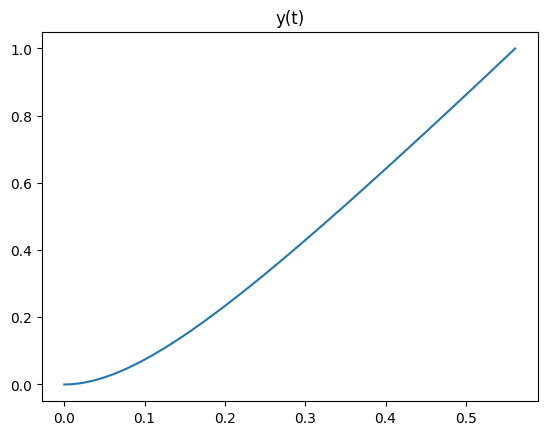

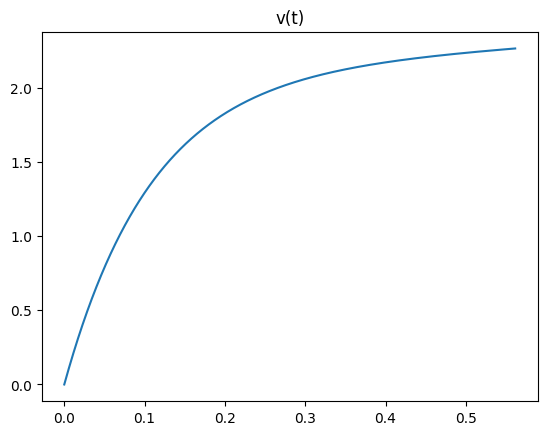

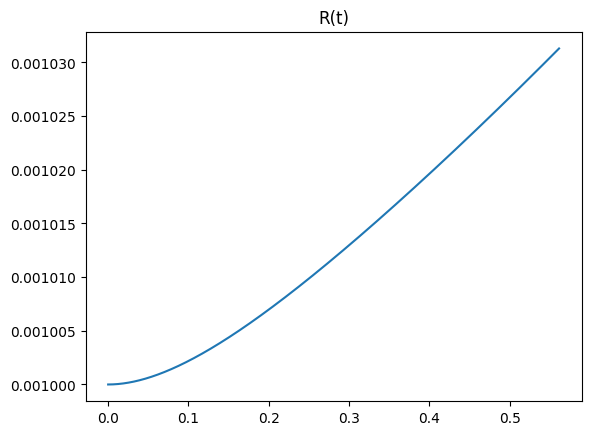

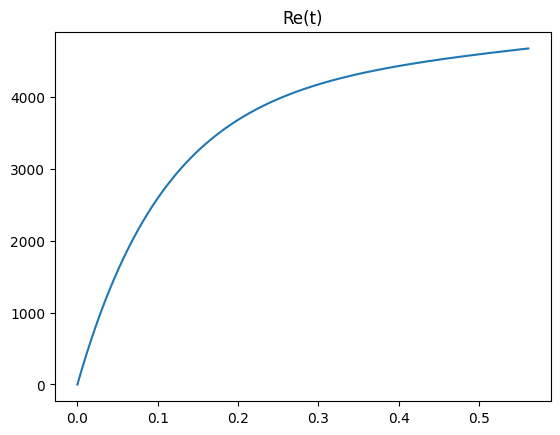

Max Reynolds number: 4669.122692598563


In [8]:
#Q1
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PARAMETERS
# ===============================
R0 = 1e-3           # initial radius (m)
H = 1.0             # height (m)
rho_l = 1000        # water density
mu = 1e-3           # viscosity
Pa = 1.013e5        # atmospheric pressure
g = 9.81

P0 = Pa + rho_l*g*H
rho_g0 = 1.2        # air density

# ===============================
# FUNCTIONS
# ===============================
def P(y):
    return Pa + rho_l*g*(H - y)

def R(y):
    return R0*(P0/P(y))**(1/3)

def V(y):
    return (4/3)*np.pi*R(y)**3

def rho_g(y):
    return rho_g0 * P(y)/P0

def meff(y):
    return rho_g(y)*V(y) + 0.5*rho_l*V(y)

# ===============================
# SYSTEM
# ===============================
def f(t, y):
    pos, v = y
    
    buoy = (rho_l - rho_g(pos))*g*V(pos)
    drag = 6*np.pi*mu*R(pos)*v
    
    acc = (buoy - drag)/meff(pos)
    
    return np.array([v, acc])

# ===============================
# RK4 (your template)
# ===============================
def rk4_step(f, t, y, h):
    k1 = f(t, y)
    k2 = f(t + h/2, y + h*k1/2)
    k3 = f(t + h/2, y + h*k2/2)
    k4 = f(t + h, y + h*k3)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# ===============================
# SIMULATION
# ===============================
dt = 1e-4
t = np.arange(0, 2, dt)

y = np.zeros((len(t),2))
y[0] = [0.0, 0.0]

for i in range(len(t)-1):
    y[i+1] = rk4_step(f, t[i], y[i], dt)
    
    if y[i+1,0] >= H:
        break

# truncate
y = y[:i+2]
t = t[:i+2]

pos = y[:,0]
vel = y[:,1]
rad = np.array([R(p) for p in pos])

# ===============================
# RESULTS
# ===============================
tsurf = t[-1]
vmax = np.max(vel)
Rfinal = rad[-1]
Vfinal = (4/3)*np.pi*Rfinal**3

print("Rise time:", tsurf)
print("Max velocity:", vmax)
print("Final radius:", Rfinal)
print("Final volume:", Vfinal)

# ===============================
# PLOTS
# ===============================
plt.figure()
plt.plot(t, pos)
plt.title("y(t)")

plt.figure()
plt.plot(t, vel)
plt.title("v(t)")

plt.figure()
plt.plot(t, rad)
plt.title("R(t)")

# Reynolds number
Re = 2*rho_l*rad*vel/mu

plt.figure()
plt.plot(t, Re)
plt.title("Re(t)")

plt.show()

print("Max Reynolds number:", np.max(Re))

# Quantum Particle in a Lennard–Jones–Like Potential

We consider a particle of mass $m$ in the Lennard Jones potential:

$$
V(x) = 4\epsilon \left[ \left(\frac{\sigma}{x}\right)^{12} - \left(\frac{\sigma}{x}\right)^6 \right], \quad x > 0
$$

---

## (a) Parabolic approximation

### Equilibrium position

At equilibrium:

$$
\frac{dV}{dx} = 0
$$

This gives:

$$
x_0 = 2^{1/6} \sigma
$$

---

### Harmonic approximation

Near $x = x_0$, expand:

$$
V(x) \approx V_{\min} + \frac{1}{2} m \omega^2 (x - x_0)^2
$$

where:

$$
\omega = \sqrt{\frac{V''(x_0)}{m}}
$$

---

## (b) Dimensionless Schrödinger equation

Define:

$$
y = \frac{x}{x_0}, \quad \lambda = \frac{E}{\epsilon}
$$

Then:

$$
-\frac{d^2 \psi}{dy^2} + U(y)\psi = \lambda \psi
$$

where:

$$
U(y) = 4\left( y^{-12} - y^{-6} \right)
$$

---

## (c) Shooting method

We solve:

$$
\psi''(y) = (U(y) - \lambda)\psi
$$

with boundary conditions:

$$
\psi(0) = 0, \quad \psi(10) = 0
$$

We:
- guess energy $\lambda$
- integrate using RK4
- adjust $\lambda$ using bisection

---

## (d) Harmonic oscillator comparison

$$
E_n^{(HO)} = V_{\min} + \hbar \omega \left(n + \frac{1}{2}\right)
$$

Error:

$$
\delta_n = 100 \frac{|E_n - E_n^{(HO)}|}{|E_n|}
$$

---

## (e) Validity condition

Quadratic approximation valid when:

$$
|x - x_0| \ll \frac{x_0}{3}
$$

Using ground state width:

$$
\langle |x - x_0| \rangle \sim \sqrt{\frac{\hbar}{m\omega}}
$$

In [18]:
import numpy as np

# ===============================
# POTENTIAL
# ===============================
def U(y):
    return 4*(y**-12 - y**-6)

# ===============================
# ODE
# ===============================
def f(y, Y, E):
    psi, phi = Y
    return np.array([phi, (U(y) - E)*psi])

# ===============================
# RK4
# ===============================
def rk4_step(f, x, y, h, E):
    k1 = f(x, y, E)
    k2 = f(x + h/2, y + h*k1/2, E)
    k3 = f(x + h/2, y + h*k2/2, E)
    k4 = f(x + h, y + h*k3, E)
    return y + h*(k1 + 2*k2 + 2*k3 + k4)/6

# ===============================
# SHOOT FROM RIGHT (IMPORTANT)
# ===============================
def shoot(E):
    ygrid = np.linspace(10, 0.9, 2000)   # integrate backward
    h = ygrid[1] - ygrid[0]

    kappa = np.sqrt(-E)

    # boundary condition at large y
    psi0 = np.exp(-kappa*ygrid[0])
    phi0 = -kappa * psi0

    Y = np.zeros((len(ygrid),2))
    Y[0] = [psi0, phi0]

    for i in range(len(ygrid)-1):
        Y[i+1] = rk4_step(f, ygrid[i], Y[i], h, E)

    # return value near turning region
    return Y[-1,0]

# ===============================
# BISECTION
# ===============================
def find_root(E1, E2):
    for _ in range(50):
        Em = 0.5*(E1+E2)
        if shoot(E1)*shoot(Em) < 0:
            E2 = Em
        else:
            E1 = Em
    return 0.5*(E1+E2)

# ===============================
# FIND STATES
# ===============================
Evals = np.linspace(-0.99, -0.01, 300)
energies = []

for i in range(len(Evals)-1):
    f1 = shoot(Evals[i])
    f2 = shoot(Evals[i+1])

    if np.sign(f1) != np.sign(f2):
        energies.append(find_root(Evals[i], Evals[i+1]))

print("Eigenvalues:", energies[:3])

Eigenvalues: []


# Planar Random Walk and Its Statistics

A particle performs a 2D random walk with step length ℓ and random direction θ ∈ [0, 2π).

---

## (a) First and second moments

Each step:
$$
x_N = \sum_{k=1}^N \ell \cos\theta_k,\quad
y_N = \sum_{k=1}^N \ell \sin\theta_k
$$

Since θ is uniform:

$$
\langle \cos\theta \rangle = 0,\quad \langle \sin\theta \rangle = 0
$$

So:
$$
\boxed{\langle x_N \rangle = \langle y_N \rangle = 0}
$$

---

### Second moments

$$
\langle x_N^2 \rangle = \sum \ell^2 \langle \cos^2\theta \rangle
$$

$$
\langle \cos^2\theta \rangle = \frac{1}{2}
$$

So:
$$
\boxed{\langle x_N^2 \rangle = \frac{N\ell^2}{2}},\quad
\boxed{\langle y_N^2 \rangle = \frac{N\ell^2}{2}}
$$

---

### Standard deviation

$$
\boxed{\sigma_x = \sigma_y = \frac{\ell\sqrt{N}}{\sqrt{2}}}
$$

---

## (b) Diffusion interpretation

Diffusion coefficient:
$$
D = \frac{\ell^2}{4\Delta t}
$$

Mean square displacement:
$$
\boxed{\langle r^2 \rangle = 4DT}
$$

---

## (d) Radial result

$$
r_N^2 = x_N^2 + y_N^2
$$

So:
$$
\boxed{\langle r_N^2 \rangle = N\ell^2}
$$

---

## (e) Central limit theorem

Averages over many steps become Gaussian:

$$
\bar{x} = \frac{1}{n} \sum \ell \cos\theta_k
$$

Variance:
$$
\boxed{\sigma^2 = \frac{\ell^2}{2n}}
$$

Mean x: 2.468510914863237e-06
Mean y: 4.056191643383744e-07
σ (simulated): 0.0005004345855781168
σ (theory): 0.0005
<r^2> (simulated): 5.000401532811213e-07
<r^2> (theory): 5e-07


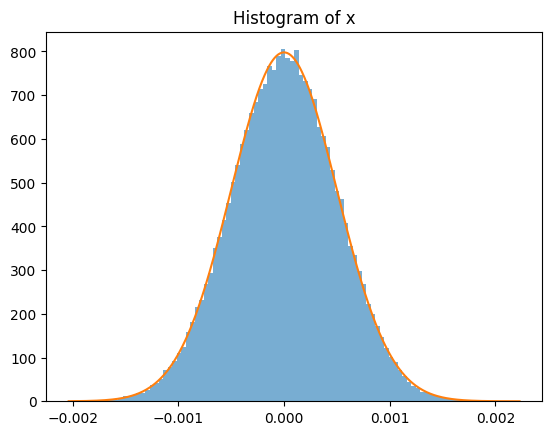

Fractional error: 0.0008813475909686969
Steps=50: sim=1.2536794831877165e-07, theory=1.25e-07
Steps=100: sim=2.50651574329124e-07, theory=2.5e-07
Steps=200: sim=5.000401532811213e-07, theory=5e-07


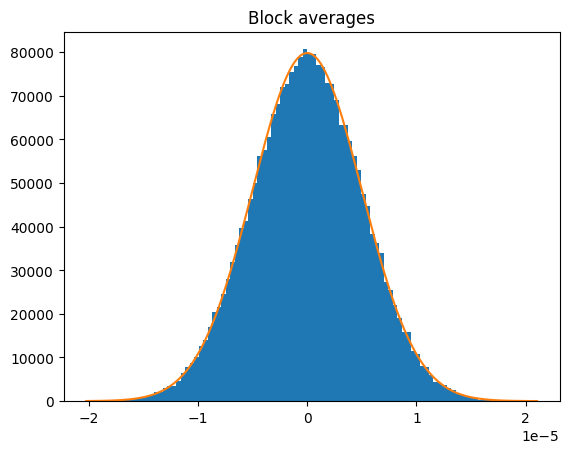

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# PARAMETERS
# ===============================
N = 200
M = 100000
l = 0.05e-3
dt = 0.01
T = N * dt

# ===============================
# RANDOM WALK
# ===============================
theta = np.random.uniform(0, 2*np.pi, (M, N))

x = np.sum(l*np.cos(theta), axis=1)
y = np.sum(l*np.sin(theta), axis=1)

# ===============================
# (a) CHECK MEAN + STD
# ===============================
print("Mean x:", np.mean(x))
print("Mean y:", np.mean(y))

sigma_x = np.std(x)
sigma_theory = l*np.sqrt(N/2)

print("σ (simulated):", sigma_x)
print("σ (theory):", sigma_theory)

# ===============================
# (b) DIFFUSION
# ===============================
D = l**2/(4*dt)
r2 = np.mean(x**2 + y**2)

print("<r^2> (simulated):", r2)
print("<r^2> (theory):", 4*D*T)

# ===============================
# (c) HISTOGRAM
# ===============================
plt.figure()

count, bins, _ = plt.hist(x, bins=100, density=True, alpha=0.6)

# Gaussian
x_vals = np.linspace(min(x), max(x), 500)
sigma = sigma_theory

gauss = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-x_vals**2/(2*sigma**2))

plt.plot(x_vals, gauss)
plt.title("Histogram of x")
plt.show()

# fractional error
sigma_est = np.sqrt(np.mean(x**2))
print("Fractional error:", abs(sigma_est - sigma)/sigma)

# ===============================
# (d) RADIAL MOMENTS
# ===============================
times = [50, 100, 200]

for n in times:
    xn = np.sum(l*np.cos(theta[:,:n]), axis=1)
    yn = np.sum(l*np.sin(theta[:,:n]), axis=1)
    
    r2_sim = np.mean(xn**2 + yn**2)
    r2_th = n*l**2
    
    print(f"Steps={n}: sim={r2_sim}, theory={r2_th}")

# ===============================
# (e) CENTRAL LIMIT
# ===============================
nblock = 50

xb = np.mean(l*np.cos(theta[:,:nblock]), axis=1)

plt.figure()
plt.hist(xb, bins=100, density=True)

sigma_block = l/np.sqrt(2*nblock)
x_vals = np.linspace(min(xb), max(xb), 500)

gauss = (1/(np.sqrt(2*np.pi)*sigma_block)) * np.exp(-x_vals**2/(2*sigma_block**2))

plt.plot(x_vals, gauss)
plt.title("Block averages")
plt.show()

# Q4. Semiclassical Energy Levels of Helium (Bohr–Sommerfeld)

We consider an effective Coulomb potential (atomic units):
\[
V_{\text{eff}}(r) = -\frac{Z_{\text{eff}}}{r}, \quad Z_{\text{eff}} = 1.6875
\]

Radial momentum:
\[
p_r(r;E,\ell) = \sqrt{2\left[E - V_{\text{eff}}(r)\right] - \frac{\ell(\ell+1)}{r^2}}
\]

---

## (a) Turning points

Turning points satisfy:
\[
2\left[E + \frac{Z_{\text{eff}}}{r}\right] - \frac{\ell(\ell+1)}{r^2} = 0
\]

Multiply by \(r^2\):
\[
2Er^2 + 2Z_{\text{eff}} r - \ell(\ell+1) = 0
\]

\[
\boxed{
r_\pm = \frac{-Z_{\text{eff}} \pm \sqrt{Z_{\text{eff}}^2 + 2E\,\ell(\ell+1)}}{2E}
}
\]

---

### Special case: \(\ell = 0\)

\[
r_- = 0
\]

\[
2Er + 2Z_{\text{eff}} = 0 \;\Rightarrow\;
\boxed{r_+ = -\frac{Z_{\text{eff}}}{E}}
\]

---

## (b) Bohr–Sommerfeld quantisation

\[
\int_{r_-}^{r_+} p_r(r;E,\ell)\,dr = \pi\left(n_r + \frac{1}{2}\right)
\]

For \(\ell = 0\):

\[
\boxed{
\int_0^{r_+(E)} \sqrt{2\left(E + \frac{Z_{\text{eff}}}{r}\right)}\,dr
=
\pi\left(n_r + \frac{1}{2}\right)
}
\]

---

### Why the factor \(1/2\)?

Due to the **turning points**, the WKB connection formula adds a phase shift of \(\pi/2\), giving \((n_r + 1/2)\).

---

## (c) Numerical method

Define action:
\[
S(E) = \int_0^{r_+(E)} p_r(r;E,0)\,dr
\]

Solve:
\[
S(E) = \pi\left(n_r + \frac{1}{2}\right)
\]

Steps:
- compute \(S(E)\) using Simpson rule
- use bisection to find \(E\)

---

## (d) Exact hydrogenic comparison

\[
E_n^{(H)} = -\frac{Z_{\text{eff}}^2}{2n^2}
\]

\[
\delta_n = 100 \times \frac{|E_n^{(BS)} - E_n^{(H)}|}{|E_n^{(H)}|}
\]

In [23]:
import numpy as np

Z = 1.6875

# -------------------------------
# turning point
# -------------------------------
def r_plus(E):
    return -Z/E

# -------------------------------
# ACTION using substitution r = u^2
# -------------------------------
def S(E):

    rp = r_plus(E)
    umax = np.sqrt(rp)

    N = 200
    u = np.linspace(0, umax, N+1)
    h = umax/N

    # avoid u=0 exactly
    u[0] = 1e-8

    val = 2*(E + Z/(u**2))
    val[val < 0] = 0

    f = 2*u * np.sqrt(val)

    S = f[0] + f[-1]
    S += 4*np.sum(f[1:-1:2])
    S += 2*np.sum(f[2:-2:2])
    S = S * (h/3)

    return S

# -------------------------------
# ROOT FINDING
# -------------------------------
def find_E(n):

    target = np.pi*(n - 0.5)

    E_scan = np.linspace(-2, -0.01, 2000)

    prev = S(E_scan[0]) - target

    for i in range(1, len(E_scan)):
        curr = S(E_scan[i]) - target

        if prev * curr < 0:
            E1 = E_scan[i-1]
            E2 = E_scan[i]

            for _ in range(50):
                Em = 0.5*(E1+E2)
                fm = S(Em) - target

                if (S(E1)-target)*fm < 0:
                    E2 = Em
                else:
                    E1 = Em

            return 0.5*(E1+E2)

        prev = curr

    return None

# -------------------------------
# COMPUTE
# -------------------------------
E_BS = []

for n in [1,2,3]:
    E_BS.append(find_E(n))

print("Bohr-Sommerfeld energies:", E_BS)

# -------------------------------
# EXACT
# -------------------------------
E_H = [-Z**2/(2*n**2) for n in [1,2,3]]
print("Exact energies:", E_H)

# -------------------------------
# ERROR
# -------------------------------
for i,n in enumerate([1,2,3]):
    err = abs(E_BS[i] - E_H[i]) / abs(E_H[i]) * 100
    print(f"n={n}, % error = {err:.3f}")

Bohr-Sommerfeld energies: [None, np.float64(-0.6327470753098059), np.float64(-0.22778894711083986)]
Exact energies: [-1.423828125, -0.35595703125, -0.158203125]


TypeError: unsupported operand type(s) for -: 'NoneType' and 'float'